#Task 3: Decision Tree Classifier on Bank Marketing Dataset
##Objective
Build a Decision Tree Classifier to predict whether a customer will subscribe to a term deposit.

Dataset Preview:
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  

Columns in Dataset:
['age', 'job', 'marital', 'education', 'default', 'balance', 

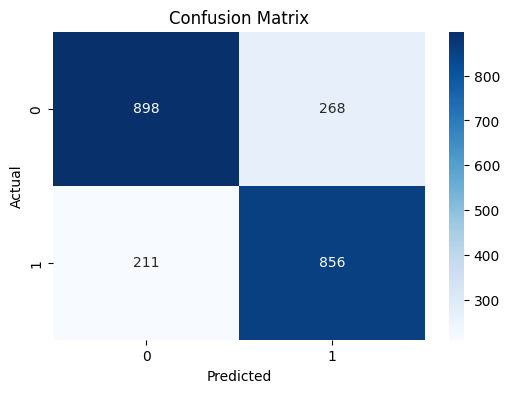


Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.77      0.79      1166
           1       0.76      0.80      0.78      1067

    accuracy                           0.79      2233
   macro avg       0.79      0.79      0.79      2233
weighted avg       0.79      0.79      0.79      2233



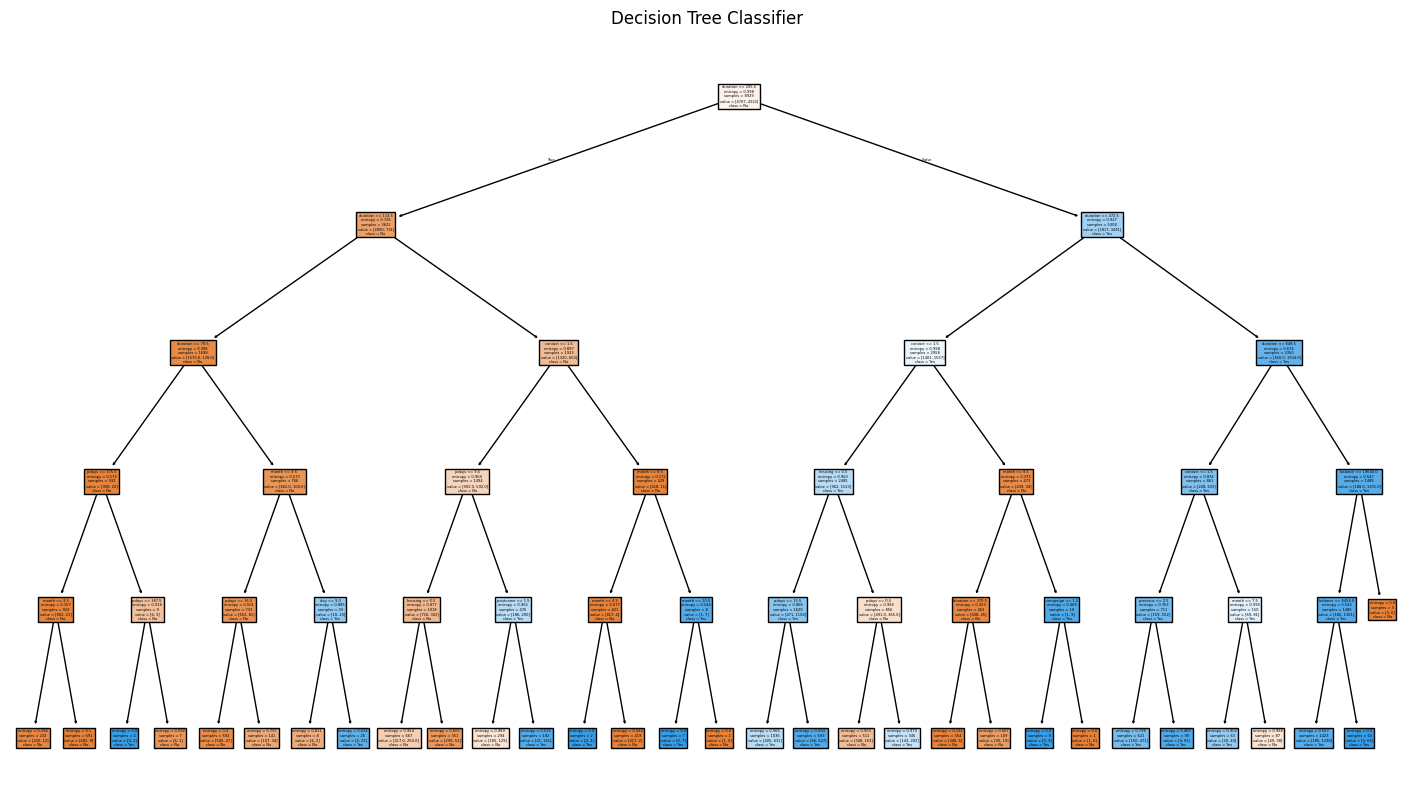


Top Important Features:
     Feature  Importance
11  duration    0.614413
8    contact    0.176685
13     pdays    0.081898
6    housing    0.052358
10     month    0.041292
15  poutcome    0.021629
5    balance    0.006178
14  previous    0.002208
9        day    0.001983
12  campaign    0.001357


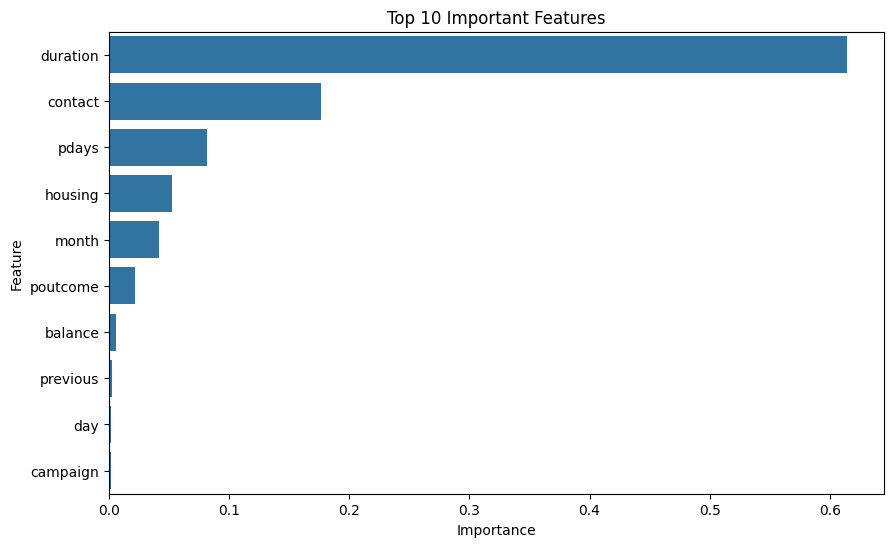

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load the bank marketing dataset
df = pd.read_csv("bank.csv")

# View first few records
print("Dataset Preview:")
print(df.head())

# Check column names
print("\nColumns in Dataset:")
print(df.columns.tolist())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Convert categorical data into numerical format
encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = encoder.fit_transform(df[column])

# Separate input features and target variable
X = df.drop("deposit", axis=1)
y = df["deposit"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train Decision Tree model
tree_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

# Make predictions
y_pred = tree_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Detailed performance report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualize the decision tree
plt.figure(figsize=(18, 10))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True
)
plt.title("Decision Tree Classifier")
plt.show()

# Find important features
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop Important Features:")
print(feature_importance.head(10))

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()